In [1]:
%load_ext autoreload
%autoreload 2

from util.data import load_data, replace_categorical, split_data, train_val_test_split, summarize_columns, normalize, mess_up_selected
from util.visualizations import plot_frequencies
from util.model import BaselineModel
from util.feature_importance import explain_model_with_shap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from util.visualizations import plot_all_features
from util.data import impute_data
from sklearn.metrics import mean_absolute_error
from util.cost_model import calculate_metrics
from util.model import L1Model
from util.model import XGBoostModel
from util.model import NeuroProbabilisticModel
from util.cost_model import CustomNeuroLoss
from util.visualizations import plot_learning_curves_neuro, plot_learning_curves_xgboost

Failed to read module file 'C:\Users\Sebastian Munthe\AppData\Local\Programs\Python\Python312\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Sebastian Munthe\Desktop\AIIndustry\Predicting-Road-Accident-Risk\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Sebastian Munthe\Desktop\AIIndustry\Predicting-Road-Accident-Risk\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sebastian Munthe\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
 

c:\Users\Sebastian Munthe\Desktop\AIIndustry\Predicting-Road-Accident-Risk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TRAIN_DATA = "data/train.csv"
TEST_DATA  = "data/test.csv"
TARGET_COL = "accident_risk"

PENALTY_UNDERESTIMATE = 5

data = load_data(TRAIN_DATA)

summarize_columns(data)

data_cleaned = replace_categorical(data)

X, Y = split_data(data_cleaned, TARGET_COL)

X_train, X_val, X_test, Y_train, Y_val, Y_test = train_val_test_split(X, Y)

features_to_normalize = ["speed_limit", "num_lanes"]
features_to_standardize = ["num_reported_accidents"]

X_train, X_val, X_test = normalize(X_train, X_val, X_test, features_to_normalize, MinMaxScaler())
X_train, X_val, X_test = normalize(X_train, X_val, X_test, features_to_standardize, StandardScaler())

Failed to read module file 'c:\Users\Sebastian Munthe\Desktop\AIIndustry\Predicting-Road-Accident-Risk\util\model_utils.py' for module 'util.model_utils': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Sebastian Munthe\Desktop\AIIndustry\Predicting-Road-Accident-Risk\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\Sebastian Munthe\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 1201: character maps to <undefined>


id: Range: 0 to 517753
road_type: Categories: ['urban', 'rural', 'highway']
num_lanes: Range: 1 to 4
curvature: Range: 0.0 to 1.0
speed_limit: Range: 25 to 70
lighting: Categories: ['daylight', 'dim', 'night']
weather: Categories: ['rainy', 'clear', 'foggy']
road_signs_present: Range: False to True
public_road: Range: False to True
time_of_day: Categories: ['afternoon', 'evening', 'morning']
holiday: Range: False to True
school_season: Range: False to True
num_reported_accidents: Range: 0 to 7
accident_risk: Range: 0.0 to 1.0


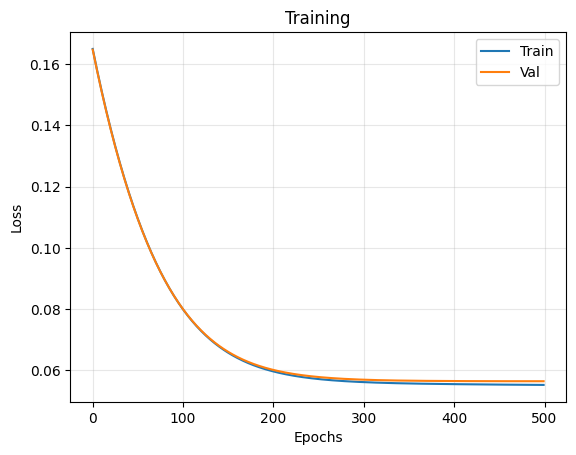

In [3]:
XGBoost = XGBoostModel()
XGBoost.fit(X_train, Y_train, eval_set=[(X_train, Y_train), (X_val, Y_val)])
results_xgboost = XGBoost.model.evals_result()

plot_learning_curves_xgboost(results_xgboost)

In [4]:
Y_predictions_xgboost = XGBoost.predict(X_test)

metrics_df = calculate_metrics(Y_test, Y_predictions_xgboost, PENALTY_UNDERESTIMATE, "XGBoost")

metrics_df

,Model,Cost,Standard MAE,RMSE,R2 Score,Underestimated portion,Overestimated portion
0,XGBoost,0.129615,0.043412,0.055967,0.88648,0.502569,0.497431


This proves that if we hadnt messed up the dataset, we would have gotten results quite close to the results of the winners of the competition as the #1 score was 0.05536 RMSE on the test dataset